In [3]:
import os
import matplotlib.pyplot as plt 
from torchvision import datasets, transforms
import numpy as np

In [9]:
DATA_DIR=r"C:\Users\Admin\Desktop\PROJECTS\defect_detection\archive\casting_data\casting_data"

In [16]:
train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

basic_tf = transforms.Compose([transforms.Resize((128,128)), transforms.ToTensor()])

train_ds = datasets.ImageFolder(train_dir, transform=basic_tf)
test_ds = datasets.ImageFolder(test_dir, transform=basic_tf)

print("classes:", train_ds.classes)
print("train size:", len(train_ds))
print("test size:", len(test_ds))

train_counts = np.bincount(train_ds.targets)
test_counts = np.bincount(test_ds.targets)
print(f"def_front: train={train_counts[0]}, test={test_counts[0]}")
print(f"ok_front: train={train_counts[1]}, test={test_counts[1]}")

classes: ['def_front', 'ok_front']
train size: 6633
test size: 715
def_front: train=3758, test=453
ok_front: train=2875, test=262


saved ../results/class_distribution.png


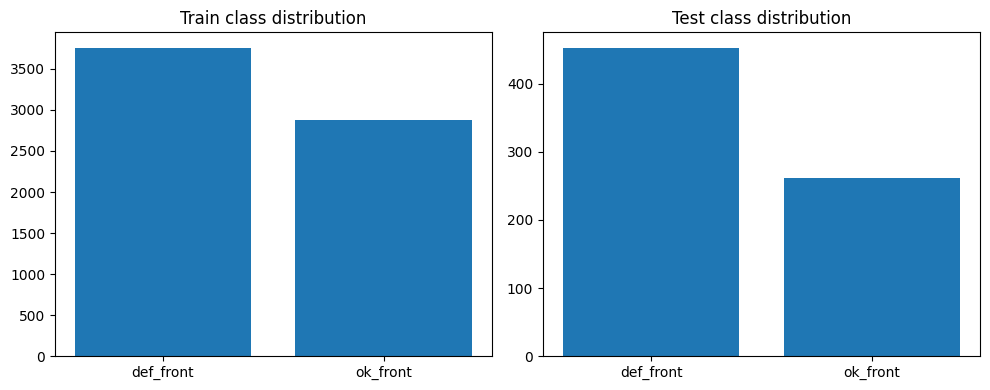

In [17]:
#plot class distribution
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].bar(train_ds.classes,train_counts)
ax[0].set_title("Train class distribution")
ax[1].bar(test_ds.classes,test_counts)
ax[1].set_title("Test class distribution")
plt.tight_layout()
os.makedirs("../results",exist_ok=True)
plt.savefig("../results/class_distribution.png")
print("saved ../results/class_distribution.png")

Saved ../results/sample_images.png


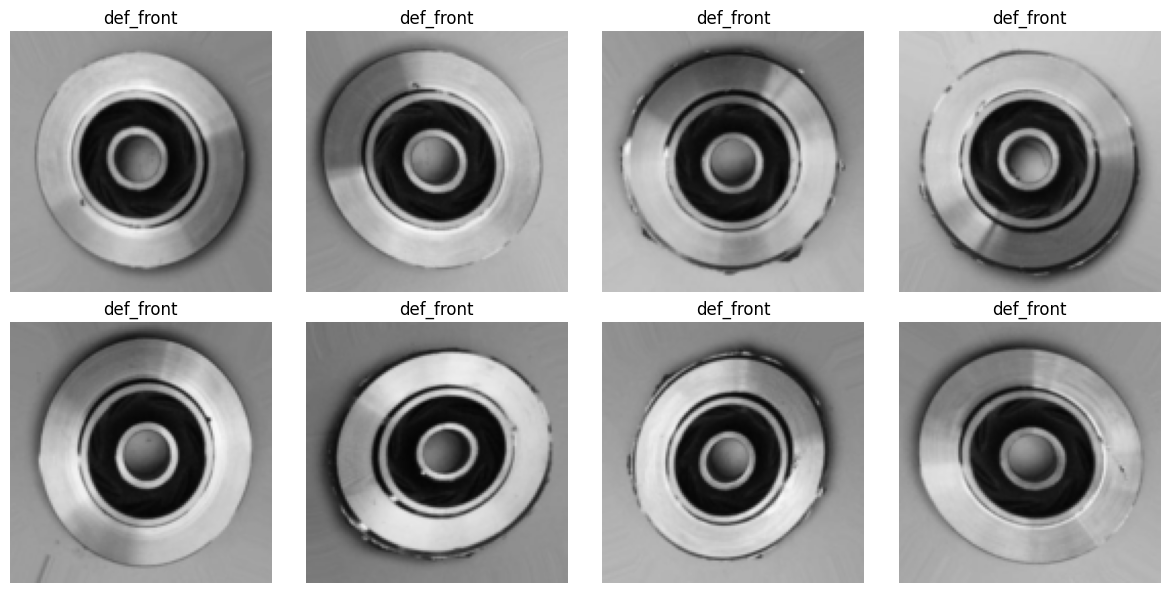

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    img, label = train_ds[i * 50 % len(train_ds)]
    axes[i // 4, i % 4].imshow(img.permute(1, 2, 0))
    axes[i // 4, i % 4].set_title(train_ds.classes[label])
    axes[i // 4, i % 4].axis("off")
plt.tight_layout()
plt.savefig("../results/sample_images.png")
print("Saved ../results/sample_images.png")